# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


digits = load_digits()
X = digits.images
y = digits.target
class_names = [str(i) for i in digits.target_names]

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training data shape: ', X_train_img.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test_img.shape)
print('Test labels shape: ', y_test.shape)


Training data shape:  (1437, 8, 8)
Training labels shape:  (1437,)
Test data shape:  (360, 8, 8)
Test labels shape:  (360,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



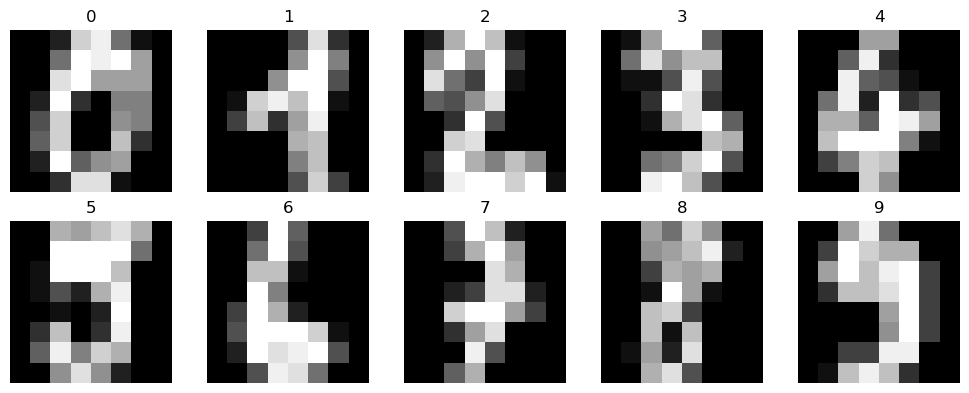

In [3]:
plt.figure(figsize=(10, 4))
for cls in range(10):
    idx = np.where(y_train == cls)[0][0]
    plt.subplot(2, 5, cls + 1)
    plt.imshow(X_train_img[idx], cmap='gray')
    plt.title(str(cls))
    plt.axis('off')
plt.tight_layout()


1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
X_train = X_train_img.reshape(X_train_img.shape[0], -1)
X_test = X_test_img.reshape(X_test_img.shape[0], -1)

print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)


X_train shape:  (1437, 64)
X_test shape:  (360, 64)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
y_test_pred = classifier.predict(X_test, k=3, num_loops=0)
print('Predicted labels shape: ', y_test_pred.shape)
print('?????? 20 ????????????:', y_test_pred[:20])


Predicted labels shape:  (360,)
?????? 20 ????????????: [5. 2. 8. 1. 7. 2. 6. 2. 6. 5. 0. 5. 9. 3. 4. 4. 2. 4. 9. 9.]


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


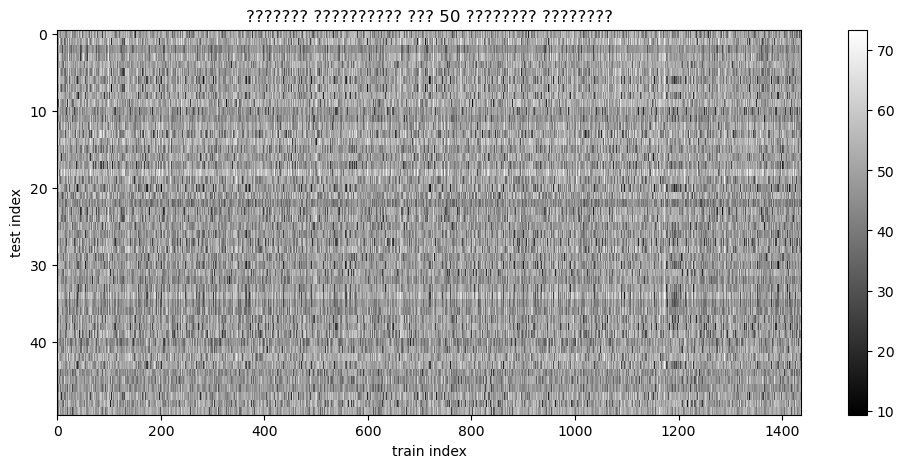

In [7]:
dists = classifier.compute_distances_no_loops(X_test[:50])
plt.figure(figsize=(12, 5))
plt.imshow(dists, aspect='auto', interpolation='nearest')
plt.colorbar()
plt.xlabel('train index')
plt.ylabel('test index')
plt.title('??????? ?????????? ??? 50 ???????? ????????')
plt.show()



1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = num_correct / y_test.shape[0]
print('Correct: %d / %d' % (num_correct, y_test.shape[0]))
print('Accuracy: %f' % accuracy)


Correct: 355 / 360
Accuracy: 0.986111


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

k = 1, accuracy = 0.9861


k = 2, accuracy = 0.9861


k = 3, accuracy = 0.9861


k = 4, accuracy = 0.9833


k = 5, accuracy = 0.9833


...

k = 11, accuracy = 0.9778


k = 12, accuracy = 0.9750


k = 13, accuracy = 0.9750


k = 14, accuracy = 0.9778


k = 15, accuracy = 0.9750


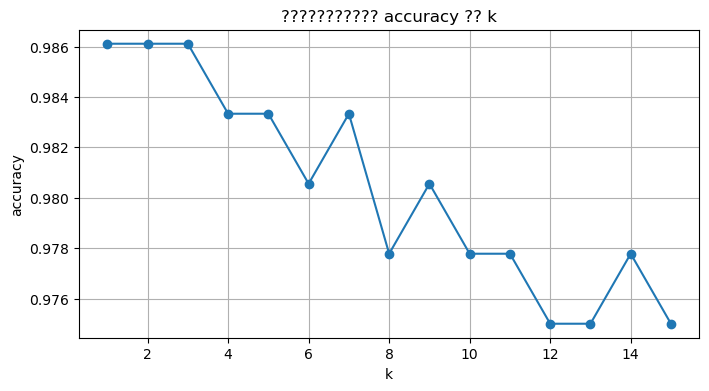

In [9]:
k_choices = list(range(1, 16))
k_accuracies = []

for k in k_choices:
    y_pred = classifier.predict(X_test, k=k, num_loops=0)
    acc = np.mean(y_pred == y_test)
    k_accuracies.append(acc)
    print('k = %d, accuracy = %.4f' % (k, acc))

plt.figure(figsize=(8, 4))
plt.plot(k_choices, k_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('??????????? accuracy ?? k')
plt.grid(True)
plt.show()


1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [10]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_to_accuracies = {}

for k in k_choices:
    fold_accuracies = []
    for train_idx, val_idx in kf.split(X_train):
        knn = KNearestNeighbor()
        knn.train(X_train[train_idx], y_train[train_idx])
        y_val_pred = knn.predict(X_train[val_idx], k=k, num_loops=0)
        fold_accuracies.append(np.mean(y_val_pred == y_train[val_idx]))
    k_to_accuracies[k] = fold_accuracies
    print('k = %d, mean cv accuracy = %.4f' % (k, np.mean(fold_accuracies)))

best_k = max(k_to_accuracies, key=lambda k: np.mean(k_to_accuracies[k]))
print('best_k =', best_k)


k = 1, mean cv accuracy = 0.9861


k = 2, mean cv accuracy = 0.9812


k = 3, mean cv accuracy = 0.9840


k = 4, mean cv accuracy = 0.9798


k = 5, mean cv accuracy = 0.9826


...

k = 11, mean cv accuracy = 0.9756


k = 12, mean cv accuracy = 0.9728


k = 13, mean cv accuracy = 0.9742


k = 14, mean cv accuracy = 0.9749


k = 15, mean cv accuracy = 0.9729
best_k = 1



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [11]:
best_knn = KNearestNeighbor()
best_knn.train(X_train, y_train)
final_knn_pred = best_knn.predict(X_test, k=best_k, num_loops=0)
final_knn_acc = np.mean(final_knn_pred == y_test)
print('Final kNN test accuracy: %.4f' % final_knn_acc)


Final kNN test accuracy: 0.9861


1.11 Сделайте выводы по результатам 1 части задания.

In [12]:
print('?????: ????? kNN ?? ?????????????? ?????? ???? ??????? ??????? ????????. ?????? ???????? ?????????? ??? k = 1: ?? ???????? ??????? accuracy ????????? 0.9861. ??? ?????????? k ???????? ??????? ?????????, ??????? ??? ???? ?????? ????????? ????? ???????? ????? ??????? ?????????.')


????? ????? ??????? ????? ????????? ???????? ?????.


## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [13]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

In [14]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [15]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [16]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [17]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [18]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


In [19]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [20]:
print('?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.')


?????? SVM ????????: ??? ???????? 4 ??????????? ??????? 1 ? 3 ?? MNIST.


2.9 Сделайте выводы по второй части задания

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [21]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


digits = load_digits()
X = digits.images.reshape(len(digits.images), -1).astype(np.float64)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

num_dev = min(200, X_train.shape[0])
X_dev = X_train[:num_dev]
y_dev = y_train[:num_dev]

print('Train: ', X_train.shape)
print('Val: ', X_val.shape)
print('Test: ', X_test.shape)
print('Dev: ', X_dev.shape)


Train:  (1149, 64)
Val:  (288, 64)
Test:  (360, 64)
Dev:  (200, 64)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

[0.00000000e+00 3.01131419e-01 5.16623151e+00 1.17780679e+01
 1.18372498e+01 5.88685814e+00 1.37859008e+00 1.37510879e-01
 4.35161010e-03 1.90252393e+00]


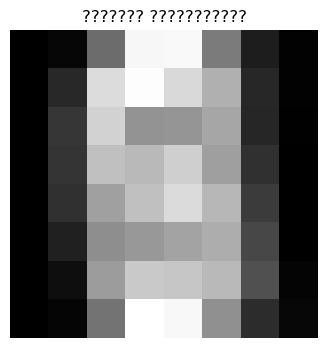

(1149, 65) (288, 65) (360, 65) (200, 65)


In [22]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((8, 8)), cmap='gray')
plt.title('??????? ???????????')
plt.axis('off')
plt.show()

X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image
X_dev = X_dev - mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)


3.4 Реализуйте функции в classifiers/softmax.py




In [23]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

W = np.random.randn(X_dev.shape[1], 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))


loss: 2.302373
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [24]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -0.488399 analytic: -0.488399, relative error: 1.418757e-10
numerical: 0.346440 analytic: 0.346440, relative error: 2.069431e-10


numerical: -0.659244 analytic: -0.659244, relative error: 4.857795e-11


numerical: -0.789683 analytic: -0.789683, relative error: 2.569020e-12
numerical: -0.180982 analytic: -0.180982, relative error: 7.389725e-10
numerical: 0.110583 analytic: 0.110583, relative error: 4.379326e-11


numerical: -0.849240 analytic: -0.849240, relative error: 1.726432e-11
numerical: 0.000505 analytic: 0.000505, relative error: 5.903702e-09


numerical: 0.720379 analytic: 0.720379, relative error: 6.135768e-11
numerical: -0.245030 analytic: -0.245030, relative error: 1.188771e-10


numerical: 0.506300 analytic: 0.506300, relative error: 5.773464e-12
numerical: 0.153461 analytic: 0.153461, relative error: 7.201162e-11


numerical: 0.103203 analytic: 0.103203, relative error: 5.446834e-10
numerical: 0.404416 analytic: 0.404416, relative error: 3.026846e-10


numerical: -0.317015 analytic: -0.317015, relative error: 2.985357e-10
numerical: 0.046577 analytic: 0.046577, relative error: 2.010507e-09


numerical: -0.012488 analytic: -0.012488, relative error: 3.477338e-10
numerical: 0.033900 analytic: 0.033900, relative error: 1.297925e-09
numerical: -0.347995 analytic: -0.347995, relative error: 3.061744e-10


numerical: -0.278921 analytic: -0.278921, relative error: 1.281663e-10


3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [25]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.302373e+00 computed in 0.029991s


vectorized loss: 2.302373e+00 computed in 0.005074s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [26]:
from scripts.classifiers import Softmax

learning_rates = [5e-3, 1e-2, 5e-2]
regularization_strengths = [1e-4, 1e-3, 1e-2]
results = {}
best_val = -1
best_softmax = None

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg,
                      num_iters=2000, batch_size=128, verbose=False)
        y_train_pred = softmax.predict(X_train)
        y_val_pred = softmax.predict(X_val)
        train_acc = np.mean(y_train == y_train_pred)
        val_acc = np.mean(y_val == y_val_pred)
        results[(lr, reg)] = (train_acc, val_acc)
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax
        print('lr %e reg %e train %.4f val %.4f' % (lr, reg, train_acc, val_acc))

best_test_pred = best_softmax.predict(X_test)
best_test_acc = np.mean(y_test == best_test_pred)
print('best validation accuracy: %.4f' % best_val)
print('best test accuracy: %.4f' % best_test_acc)


lr 5.000000e-03 reg 1.000000e-04 train 0.9974 val 0.9757


lr 5.000000e-03 reg 1.000000e-03 train 0.9965 val 0.9757


lr 5.000000e-03 reg 1.000000e-02 train 0.9948 val 0.9757


lr 1.000000e-02 reg 1.000000e-04 train 0.9983 val 0.9722


lr 1.000000e-02 reg 1.000000e-03 train 1.0000 val 0.9722


lr 1.000000e-02 reg 1.000000e-02 train 0.9983 val 0.9757


lr 5.000000e-02 reg 1.000000e-04 train 1.0000 val 0.9688


lr 5.000000e-02 reg 1.000000e-03 train 1.0000 val 0.9688


lr 5.000000e-02 reg 1.000000e-02 train 0.9991 val 0.9688
best validation accuracy: 0.9757
best test accuracy: 0.9611


3.10 Сделайте выводы по третьей части задания

In [27]:
print('?????: ?????????? Softmax ???????? ?????????, ??? ??? ??????? ? ??????????????? ?????? ???? ?????????? ???????? loss ? gradient. ????? ??????? ??????????????? ?????? accuracy ?? ????????? ????????? 0.9757, ? ?? ???????? ??????? 0.9611. ??? ??????? ???? kNN, ?? ?????? ????????? ??????? ? ???? ?????????? ?????????.')


????? ????? ??????? ????? ????????? ???????? ?????.
